# Lasso and Ridge Regression in Python Tutorial
This notebook covers theory, intuition, and implementation of Linear, Ridge, and Lasso Regression.

## 1. Introduction to Linear Regression
Linear regression models the relationship between input features and output:

y = b0 + b1x1 + b2x2 + ... + bnxn

The goal is to minimize prediction error using a cost function.

## 2. What is Regularization?
Regularization helps prevent overfitting by penalizing large coefficients.

- Overfitting: model performs well on training but poorly on test data
- Underfitting: model performs poorly everywhere

Regularization reduces model complexity.

## 3. Lasso Regression (L1)
Lasso adds absolute penalty:

Loss = RSS + λ * Σ|β|

- Shrinks coefficients
- Can make some coefficients exactly zero
- Useful for feature selection

## 4. Ridge Regression (L2)
Ridge adds squared penalty:

Loss = RSS + λ * Σ(β²)

- Shrinks coefficients
- Never makes them zero
- Handles multicollinearity well

#  Coefficient (coef) in Machine Learning

##  1. What is a Coefficient?

In a linear regression model:

y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ

- Each **β (beta)** is called a **coefficient (coef)**
- It represents the **impact of a feature on the output**

 In simple words:
> A coefficient tells how much the output changes when a feature changes.

---

##  2. Intuition

If:
- β₁ = 5  

 Interpretation:
- If x₁ increases by 1 → y increases by 5

---

##  3. Real-World Example (House Price)

Model:
Price = 50,000 + 300 × Size + 10,000 × Rooms

| Feature | Coefficient | Meaning |
|--------|------------|--------|
| Size   | 300        | +1 sq ft → +300 price |
| Rooms  | 10,000     | +1 room → +10,000 price |

---

##  4. Types of Coefficients

###  Positive Coefficient (+)
- Feature ↑ → Output ↑  
Example: More experience → higher salary  

---

###  Negative Coefficient (−)
- Feature ↑ → Output ↓  
Example: More distance → lower house price  

---

##  5. Why Coefficients Matter

### 1. Feature Importance
- Larger coefficient → more influence

### 2. Decision Making
- Helps identify important variables

### 3. Interpretability
- Used in business, healthcare, economics

---

##  6. Problems with Coefficients

###  Multicollinearity
- Coefficients become unstable  
Example:
- Size = +300  
- Rooms = -5000 ❗ (incorrect sign)

---

###  Feature Scaling Issue
- Features with large values dominate coefficients  

 Solution:
- Use StandardScaler

---

##  7. Effect of Regularization

###  Ridge Regression
- Shrinks coefficients  
Example:
- 300 → 150  

---

###  Lasso Regression
- Shrinks and removes features  
Example:
- 300 → 0 (feature eliminated)  

---

##  8. Real-World Impact

###  Business Example
Sales = 1000 + 50 × Ads + 10 × Emails  

 Ads have more impact → invest more in ads  

---

###  Healthcare Example
- Age coef = +0.8  
- Exercise coef = −1.2  

 Exercise reduces disease risk  

---

##  Final Intuition

> Coefficient = "impact strength" of a feature on output

---

##  Summary

| Concept | Meaning |
|--------|--------|
| Coefficient | Effect of feature on output |
| Positive | Direct relationship |
| Negative | Inverse relationship |
| Large value | Strong impact |
| Lasso | Can make coef = 0 |
| Ridge | Shrinks coef |

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

In [5]:
# Load dataset
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['PRICE'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


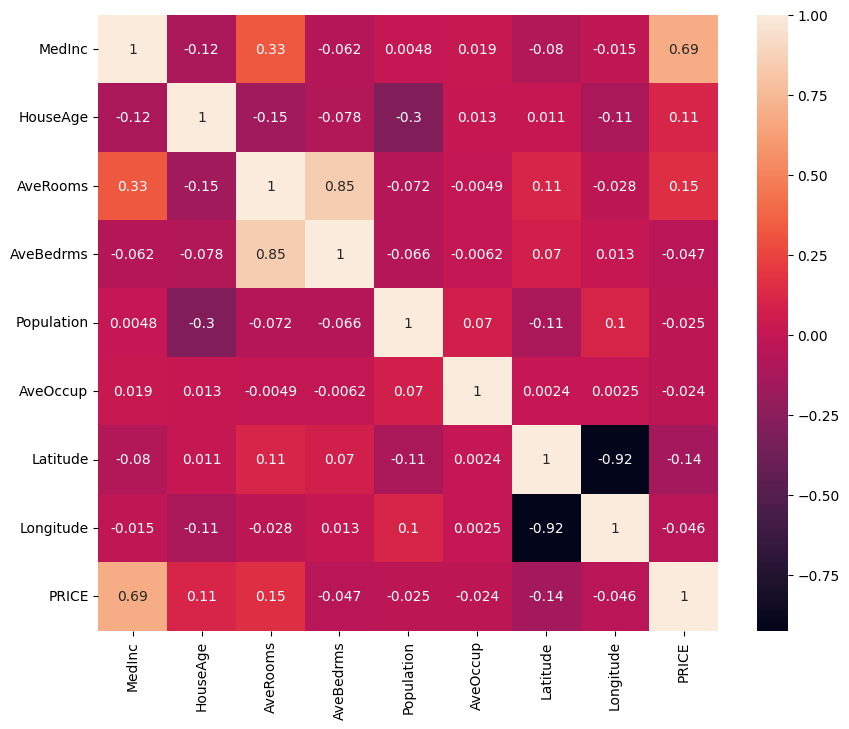

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [8]:
# Split data
X = df.drop('PRICE', axis=1)
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

print('Train Score:', lr.score(X_train, y_train))
print('Test Score:', lr.score(X_test, y_test))

Train Score: 0.6093459727972159
Test Score: 0.5957702326061665


In [ ]:
# Ridge Regression
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

print('Train Score:', ridge.score(X_train, y_train))
print('Test Score:', ridge.score(X_test, y_test))

Train Score: 0.6093371291442486
Test Score: 0.5959440604913041


In [ ]:
# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print('Train Score:', lasso.score(X_train, y_train))
print('Test Score:', lasso.score(X_test, y_test))

Train Score: 0.4938699875226864
Test Score: 0.49349221700165646


In [ ]:
# Create coefficient comparison table
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

# Set feature as index (optional, cleaner view)
coef_df.set_index("Feature", inplace=True)

# Display table
coef_df

,Linear,Ridge,Lasso
Feature,,,
MedInc,0.849222,0.848519,0.708327
HouseAge,0.122119,0.123001,0.106594
AveRooms,-0.299558,-0.297069,-0.000000
AveBedrms,0.348410,0.345349,0.000000
Population,-0.000884,-0.000585,-0.000000
AveOccup,-0.041698,-0.041741,-0.000000
Latitude,-0.893856,-0.885416,-0.010425
Longitude,-0.868617,-0.860056,-0.000000


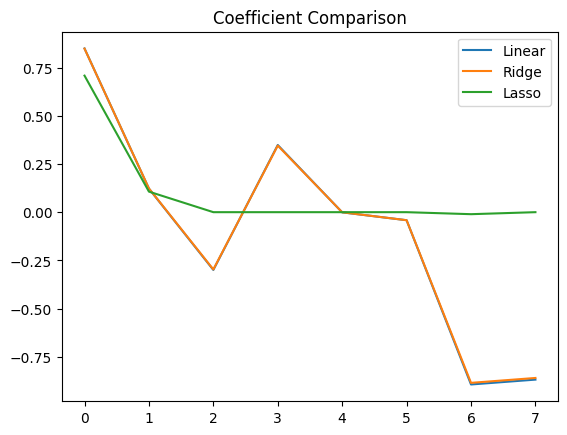

In [ ]:
# Compare coefficients
plt.figure()
plt.plot(lr.coef_, label='Linear')
plt.plot(ridge.coef_, label='Ridge')
plt.plot(lasso.coef_, label='Lasso')
plt.legend()
plt.title('Coefficient Comparison')
plt.show()

## 5. Key Takeaways
- Ridge reduces coefficient size but keeps all features
- Lasso can remove features completely
- Both help prevent overfitting
- Choose alpha carefully using cross-validation